# Example usage

In [73]:
import sys
!{sys.executable} -m pip install biosonic[praat]

zsh:1: no matches found: biosonic[praat]


In [74]:
from biosonic import handle, plot, compute, filter


## Read file and plot spectrogram

In [75]:
data_folder = "./example_data/"

In [76]:
data, sr, n_ch, quant = handle.read_wav(data_folder+"GT00024_G00219_Dagobert_distance.wav")
print(f"sampling rate: {sr}, number of channels: {n_ch}, quantization: {quant}")

sampling rate: 44100, number of channels: 1, quantization: float32


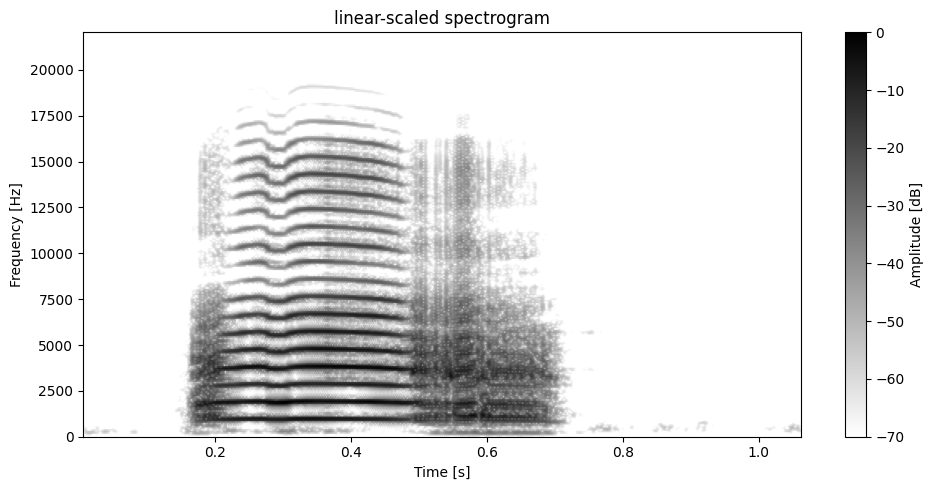

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'linear-scaled spectrogram'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [77]:
WINDOW_LENGTH = 512
DYNAMIC_RANGE = 70

plot.plot_spectrogram(data, sr=sr, window_length=WINDOW_LENGTH, overlap=95, dynamic_range=DYNAMIC_RANGE)

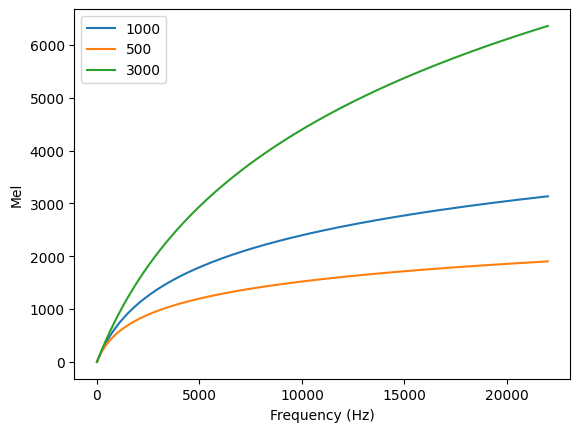

In [78]:
import numpy as np
import matplotlib.pyplot as plt

hz = np.linspace(0, 22000, 1000)
mel= compute.utils.hz_to_mel(hz, corner_frequency=1000)
plt.plot(hz, mel, label="1000")
mel= compute.utils.hz_to_mel(hz, corner_frequency=500)
plt.plot(hz, mel, label="500")
mel= compute.utils.hz_to_mel(hz, corner_frequency=3000)
plt.plot(hz, mel, label="3000")

plt.legend()
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mel")
plt.show()

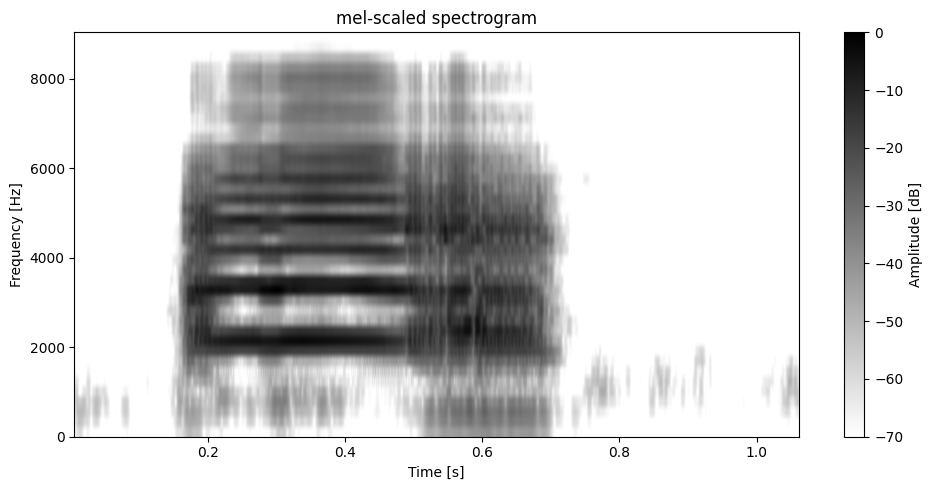

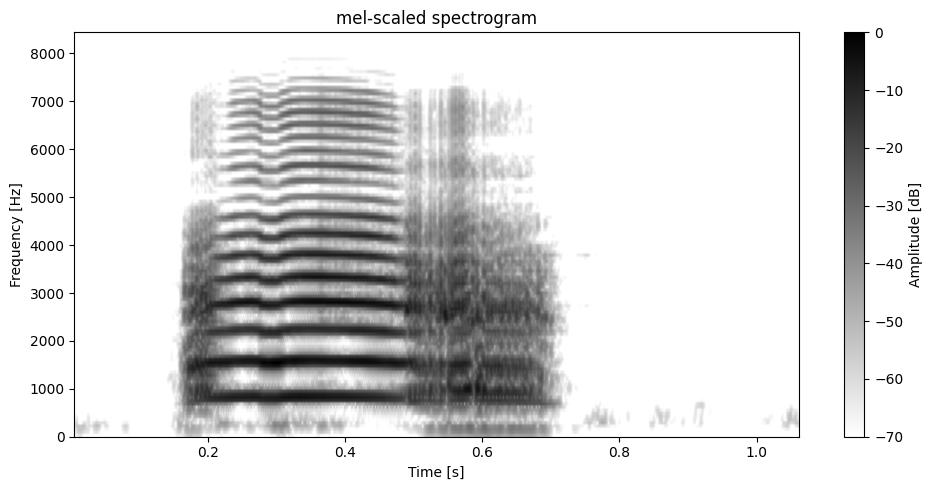

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'mel-scaled spectrogram'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [79]:
plot.plot_spectrogram(data, sr=sr, window_length=WINDOW_LENGTH, overlap=95, dynamic_range=DYNAMIC_RANGE, freq_scale="mel", n_bands=40)
plot.plot_spectrogram(data, sr=sr, window_length=WINDOW_LENGTH, overlap=95, dynamic_range=DYNAMIC_RANGE, freq_scale="mel", n_bands=128, corner_frequency=5000)

In [80]:
# import librosa

# S = librosa.feature.melspectrogram(y=data, sr=sr, n_fft=WINDOW_LENGTH, n_mels=128)
# fig, ax = plt.subplots()
# S_dB = librosa.power_to_db(S, ref=np.max)
# img = librosa.display.specshow(S_dB, x_axis='time',
#                          y_axis='mel', sr=sr, ax=ax, cmap="binary")
# fig.colorbar(img, ax=ax, format='%+2.0f dB') 
# ax.set(title='Mel-frequency spectrogram')

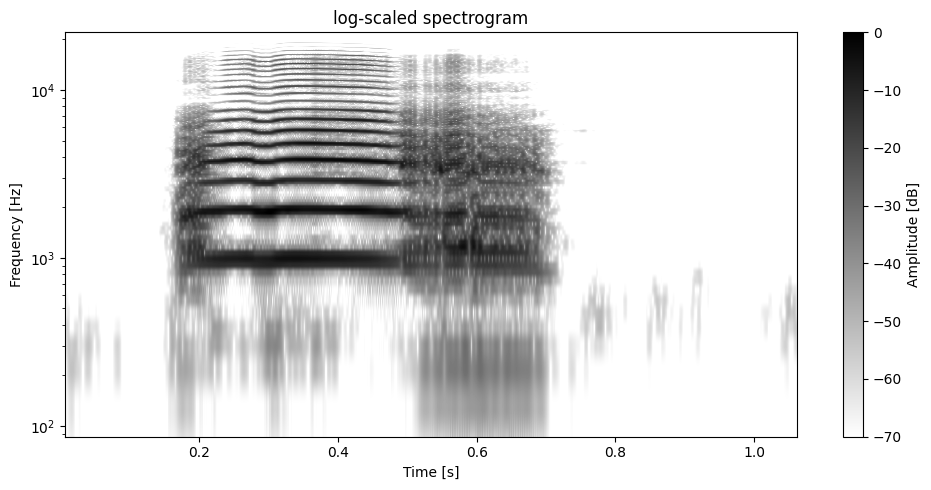

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'log-scaled spectrogram'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [81]:
plot.plot_spectrogram(data, sr=sr, window_length=WINDOW_LENGTH, overlap=95, dynamic_range=DYNAMIC_RANGE, freq_scale="log")

## Cepstrum and cepstral coefficients

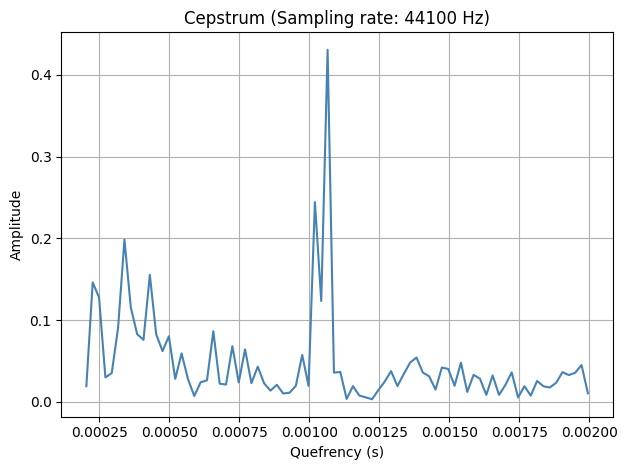

In [82]:
ceps = compute.spectrotemporal.cepstrum(data, sr)
plot.plot_cepstrum(data, sr, max_quefrency=1/500, min_quefrency=1/5000)

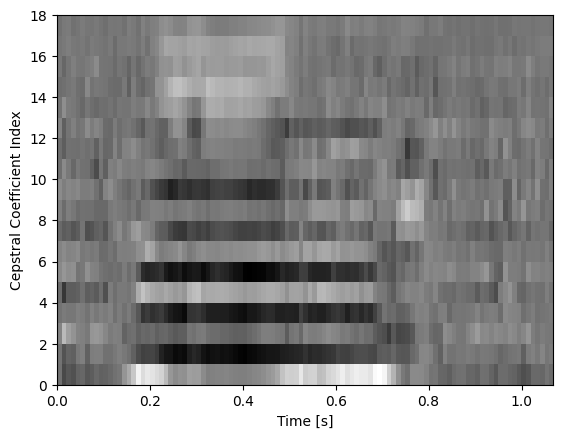

In [83]:
plot.plot_cepstral_coefficients(data, sr, WINDOW_LENGTH, filterbank_type="log", n_ceps=18, fmin=2000)

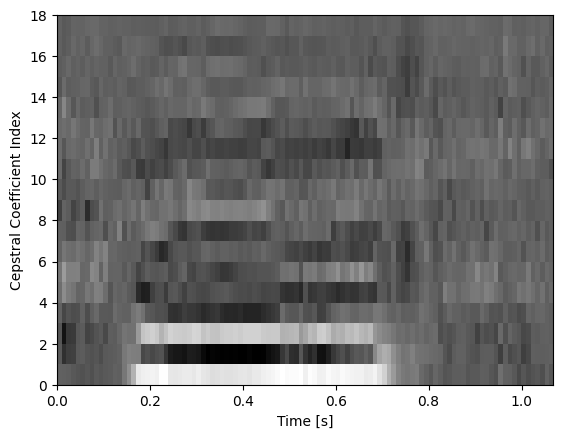

In [84]:
plot.plot_cepstral_coefficients(data, sr, WINDOW_LENGTH, filterbank_type="linear", n_ceps=18, fmin=2000)

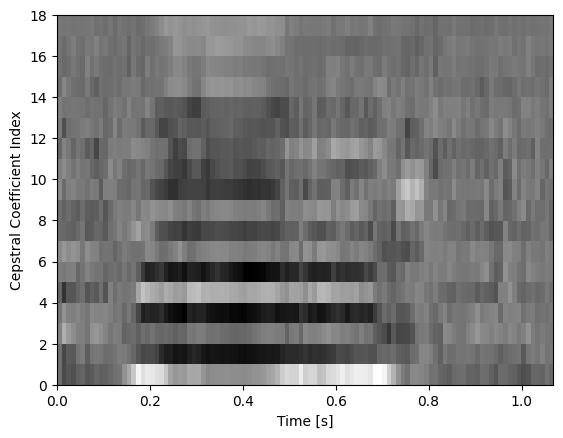

In [85]:
plot.plot_cepstral_coefficients(data, sr, WINDOW_LENGTH, filterbank_type="mel", n_ceps=18, fmin=2000)

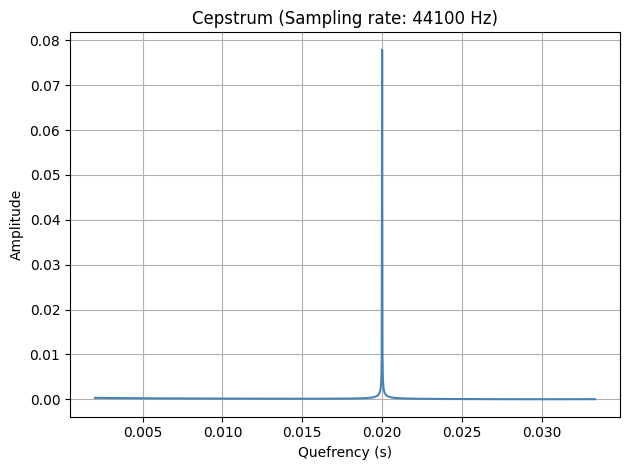

In [86]:
from scipy.signal import sawtooth
perios_s = 1
times = np.linspace(0, perios_s, perios_s * 44100)
f_Hz = 50
# sine_w = np.sin(2 * np.pi * f_Hz * times) + np.sin(2 * np.pi * f_Hz*2 * times)

saw = sawtooth(2 * np.pi * f_Hz * times)
# plt.plot(times, sine_w)
# plt.show()
plot.plot_cepstrum(saw, sr, min_quefrency=1/500, max_quefrency=1/30)

## Filter signal

sampling rate: 44100, number of channels: 1, quantization: float32


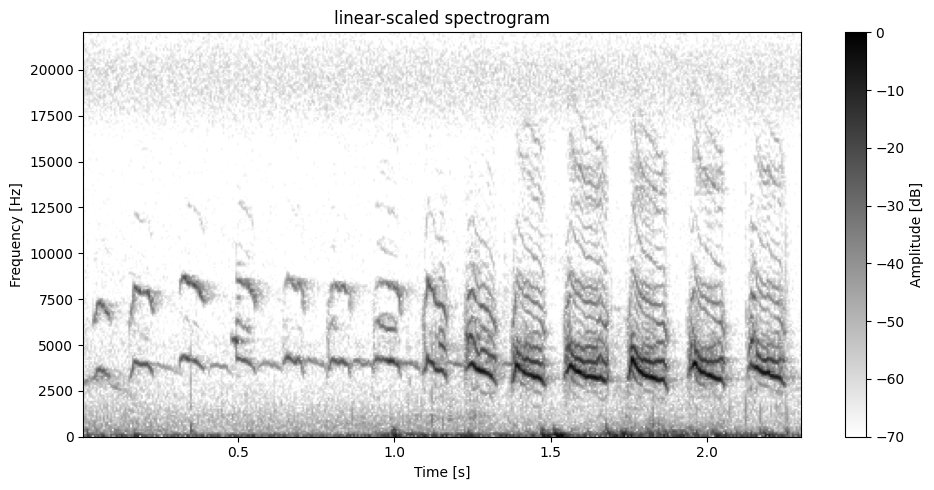

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'linear-scaled spectrogram'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [87]:
data, sr, n_ch, quant = handle.read_wav(data_folder+"/201.wav")
print(f"sampling rate: {sr}, number of channels: {n_ch}, quantization: {quant}")
plot.plot_spectrogram(data, sr, dynamic_range=DYNAMIC_RANGE)

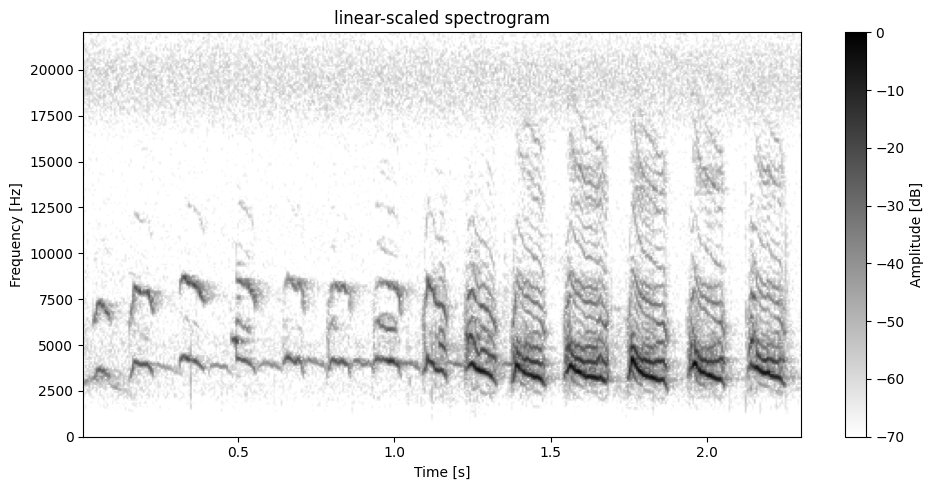

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'linear-scaled spectrogram'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [88]:
x_filtered = filter.filter(data, sr, f_cutoff=2500, type="highpass")
plot.plot_spectrogram(x_filtered, sr, dynamic_range=DYNAMIC_RANGE)

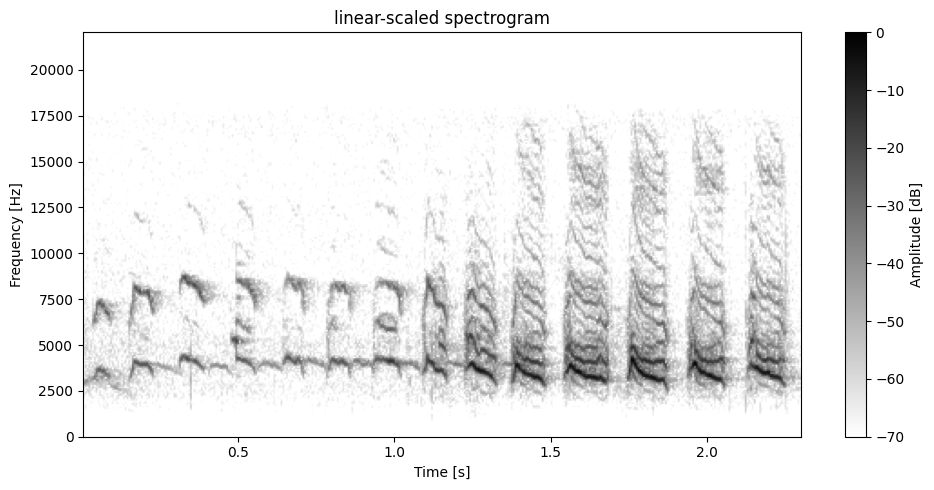

(<Figure size 1000x500 with 2 Axes>,
 <Axes: title={'center': 'linear-scaled spectrogram'}, xlabel='Time [s]', ylabel='Frequency [Hz]'>)

In [89]:
# change order for steeper frequency cutoff
x_filtered = filter.filter(x_filtered, sr, f_cutoff=17500, type="lowpass", order=4)
plot.plot_spectrogram(x_filtered, sr, dynamic_range=DYNAMIC_RANGE)

## Pitch tracking

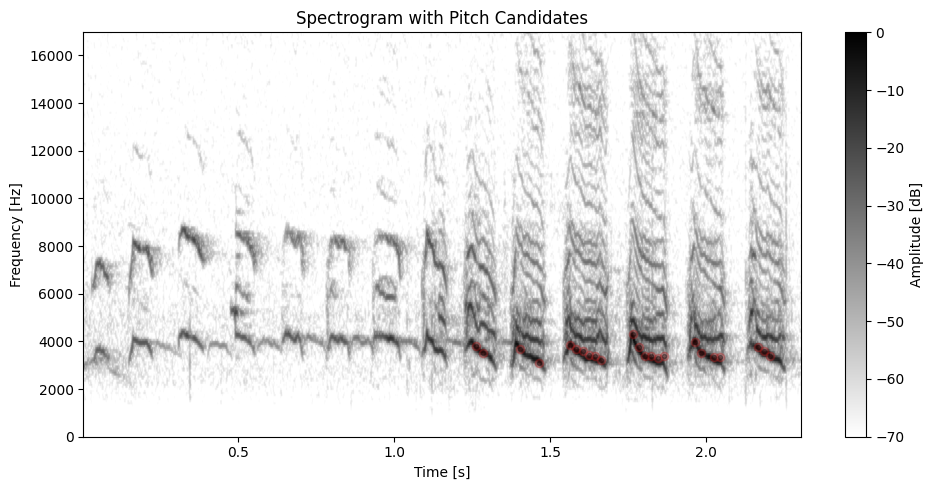

In [90]:
# praat autocorrelation pitch tracking
time_points, candidates ,_ ,_= compute.pitch.boersma(x_filtered, sr, min_pitch=2000, max_pitch=6000, voicing_thresh=.3, timestep=0.02, octave_cost=0.03, silence_thresh=0.05, plot=True, window_length=WINDOW_LENGTH, overlap=95, flim=(0,17000), dynamic_range=DYNAMIC_RANGE)

## Audio feature extraction

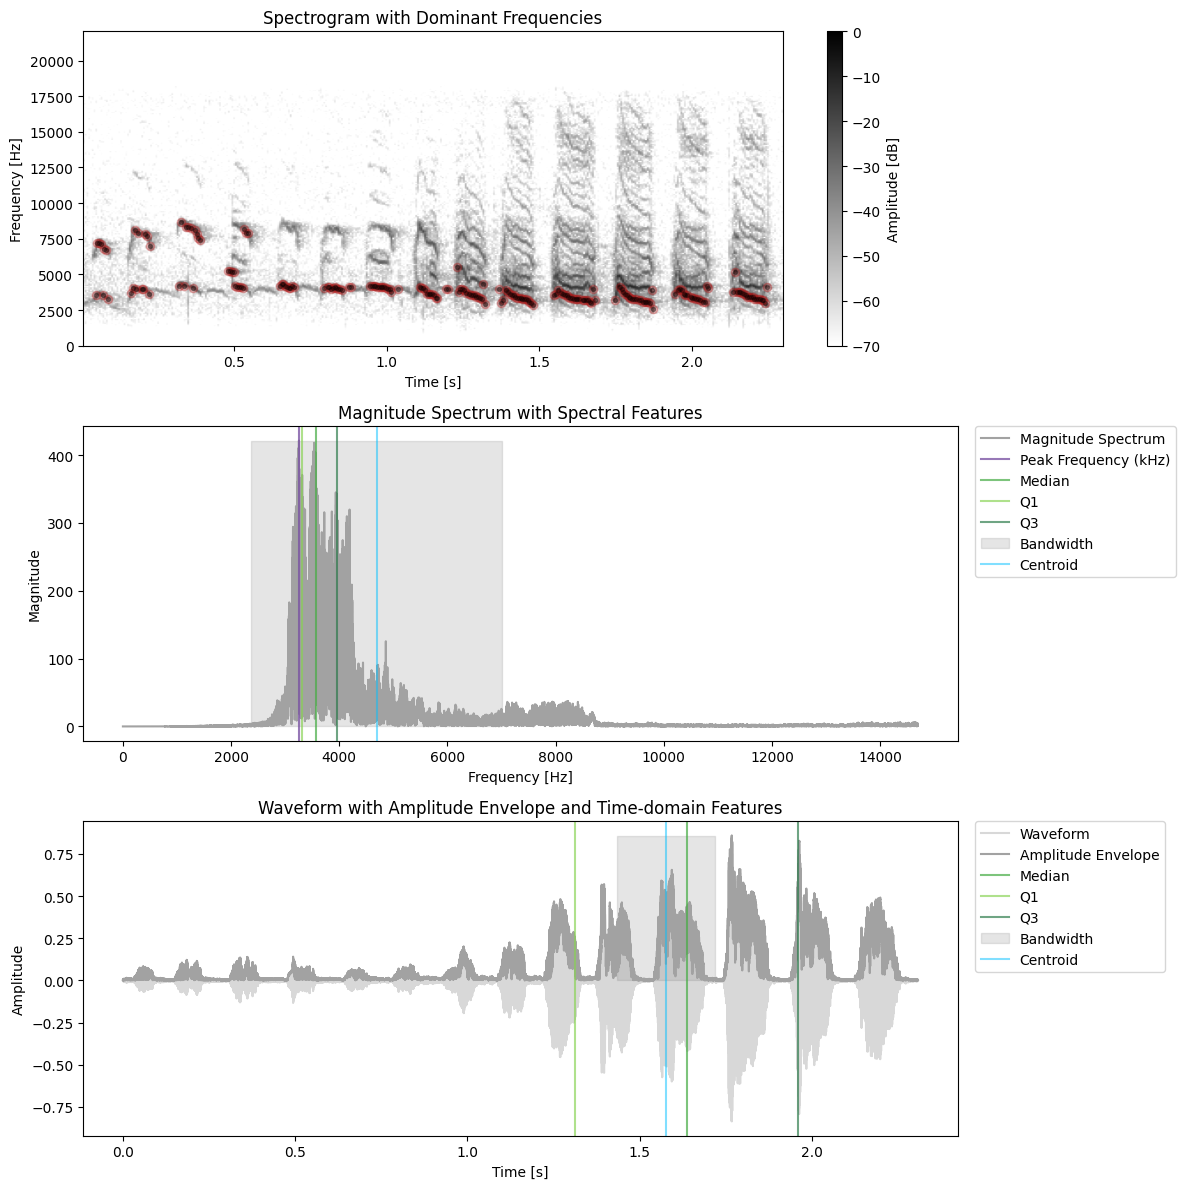

In [91]:
features = compute.utils.extract_all_features(x_filtered, sr, min_prominence=0.7, noise_threshold=0.5, plot=True, spec_kwargs={"dynamic_range": DYNAMIC_RANGE}) # lower resolution for dom freqs?

In [92]:
features # percentile based duration? #TODO spectral flux - more parameters

{'t_q1': 1.3120634920634922,
 't_median': 1.635986394557823,
 't_q3': 1.96,
 'temporal_centroid': np.float64(1.575421034756307),
 'temporal_sd': 0.14219745993614197,
 'temporal_skew': 1.701041579246521,
 'temporal_kurtosis': 2.3180131912231445,
 'amplitude_envelope': array([0.00216412, 0.00484224, 0.00438172, ..., 0.00178456, 0.00274392,
        0.00248053], shape=(101762,), dtype=float32),
 'duration': 2.307482993197279,
 'temporal_entropy': 0.6972431441258984,
 'fq_q1': np.float64(3319.135826732965),
 'fq_median': np.float64(3570.920382854111),
 'fq_q3': np.float64(3950.1139914702935),
 'spectral_flatness': np.float32(0.00031226903),
 'spectral_centroid': np.float64(4689.2712607487265),
 'spectral_sd': np.float64(2320.8410518589726),
 'spectral_skew': np.float64(2.8069179393064907),
 'spectral_kurtosis': np.float64(12.066579155497605),
 'peak_frequency': 3254.564572237181,
 'pse': 0.7195254033497382,
 'spectrotemporal_entropy': 0.5016841545100267,
 'dominant_freqs': array([         n

## Batch normalize files in a folder and export features as csv

In [93]:
handle.batch_normalize_wav_files(data_folder, 44100, 1, "float32")

Normalized: 307.wav -> example_data/normalized/307.wav
Normalized: GT00025_G00220_Jafar_distance.wav -> example_data/normalized/GT00025_G00220_Jafar_distance.wav
Normalized: GT00024_G00219_Dagobert_distance.wav -> example_data/normalized/GT00024_G00219_Dagobert_distance.wav
Normalized: 201.wav -> example_data/normalized/201.wav


In [94]:
features_df = handle.batch_extract_features(data_folder+"/normalized", save_csv_path="extracted_features.csv")

processing 307.wav
processing GT00025_G00220_Jafar_distance.wav
processing GT00024_G00219_Dagobert_distance.wav
processing 201.wav
Features saved to: example_data/normalized/extracted_features.csv


In [95]:
features_df

,t_q1,t_median,t_q3,temporal_centroid,temporal_sd,temporal_skew,temporal_kurtosis,amplitude_envelope,duration,temporal_entropy,...,peak_frequency,pse,spectrotemporal_entropy,dominant_freqs,mean_dom,min_dom,max_dom,range_dom,mod_dom,filename
0,0.599138,0.817007,1.027755,0.798299,0.179693,1.242794,0.902816,"[0.06161315, 0.040482312, 0.045260396, 0.03598...",1.363923,0.834523,...,64.959203,0.773999,0.645920,"[86.1328125, 86.1328125, nan, nan, nan, 172.26...",3016.823509,86.132812,6546.093750,6459.960938,26.866667,307.wav
1,0.448503,0.618821,0.762358,0.596150,0.088544,0.675407,-0.359200,"[1.2039241e-06, 1.013242e-05, 8.4458674e-07, 7...",1.229841,0.747798,...,1334.680467,0.457769,0.342319,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",1496.796875,947.460938,3789.843750,2842.382812,10.272727,GT00025_G00220_Jafar_distance.wav
2,0.295850,0.378707,0.466259,0.391263,0.156971,1.738432,3.013786,"[0.00063974044, 0.0004664516, 0.0004338555, 0....",1.065283,0.599751,...,1904.728941,0.684076,0.410275,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...",2371.343994,775.195312,3789.843750,3014.648438,17.371429,GT00024_G00219_Dagobert_distance.wav
3,1.289433,1.607664,1.873061,1.533715,0.172133,1.484266,1.465634,"[0.06590071, 0.046115156, 0.04068432, 0.040628...",2.304331,0.791094,...,45.936597,0.719736,0.569379,"[2928.515625, 344.53125, nan, nan, 86.1328125,...",2844.820534,86.132812,8699.414062,8613.281250,42.490000,201.wav


## Parse praat TextGrids and extract segments from file
This relies on the praat-textgrids library written by Tommi Nieminen:

https://github.com/Legisign/Praat-textgrids

In [96]:
data, sr, _, _ = handle.read_wav(data_folder+"/201.wav", n_channels=1)

In [97]:
# get boundaries and plot
segments = handle.boundaries_from_textgrid(data_folder+"/201.TextGrid", tier_name="segments")

In [98]:
segments

[{'label': '1', 'begin': 0.03192743764172336, 'end': 0.09225804535141492},
 {'label': '2', 'begin': 0.14802721088435375, 'end': 0.22507401889130346},
 {'label': '3', 'begin': 0.3076643990929705, 'end': 0.3885398324788586},
 {'label': '4', 'begin': 0.47020408163265304, 'end': 0.5659863945578232},
 {'label': '5', 'begin': 0.6443537414965986, 'end': 0.7140136054421768},
 {'label': '6', 'begin': 0.7923809523809524, 'end': 0.8591383219954648},
 {'label': '7', 'begin': 0.9346031746031747, 'end': 1.0199265374607902},
 {'label': '8', 'begin': 1.08843537414966, 'end': 1.1690890923594341},
 {'label': '9', 'begin': 1.224258804445234, 'end': 1.3284682606073004},
 {'label': '10', 'begin': 1.3754646820137224, 'end': 1.4858041061853222},
 {'label': '11', 'begin': 1.5430171409409665, 'end': 1.6880930504999216},
 {'label': '12', 'begin': 1.7432627625857215, 'end': 1.8781220587954544},
 {'label': '13', 'begin': 1.933061224489796, 'end': 2.072380952380952},
 {'label': '14', 'begin': 2.124625850340136, 'e

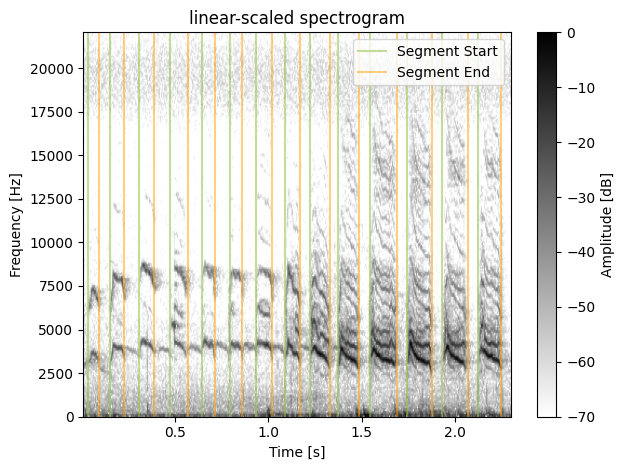

In [99]:
plot.plot_boundaries_on_spectrogram(data, sr, segments, dynamic_range=DYNAMIC_RANGE)

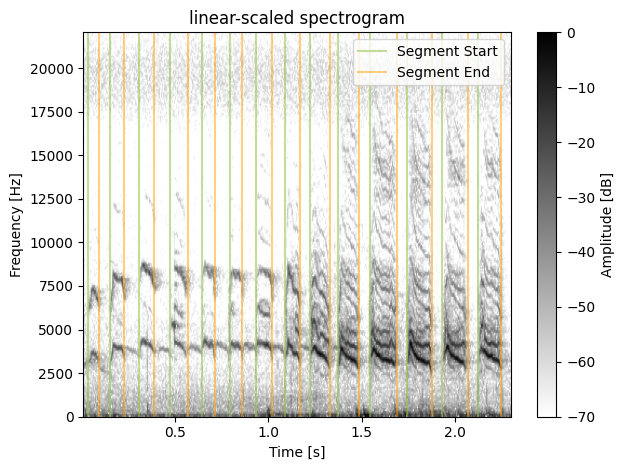

In [100]:
# or extract signal segments directly
audio_segments = handle.audio_segments_from_textgrid(data, sr, data_folder+"/201.TextGrid", tier_name="segments", dynamic_range=DYNAMIC_RANGE)

In [101]:
audio_segments

,waveform,label,sr,filename
0,"[0.025147252, 0.018524736, 0.026093327, 0.0258...",1,44100,201.TextGrid
1,"[0.020172736, 0.015442366, 0.020172736, 0.0142...",2,44100,201.TextGrid
2,"[-0.054597612, -0.057924133, -0.058381908, -0....",3,44100,201.TextGrid
3,"[0.032258064, 0.029877622, 0.025849178, 0.0291...",4,44100,201.TextGrid
4,"[0.045014802, 0.053559985, 0.04809717, 0.04147...",5,44100,201.TextGrid
5,"[-0.0018311106, -0.0053712577, -0.021454513, -...",6,44100,201.TextGrid
6,"[0.005279702, 0.0128482925, 0.011902219, 0.008...",7,44100,201.TextGrid
7,"[0.09707938, 0.09140293, 0.09353923, 0.0873744...",8,44100,201.TextGrid
8,"[-0.09341716, -0.08297983, -0.077547535, -0.06...",9,44100,201.TextGrid
9,"[-0.047029022, -0.043946654, -0.034943692, -0....",10,44100,201.TextGrid


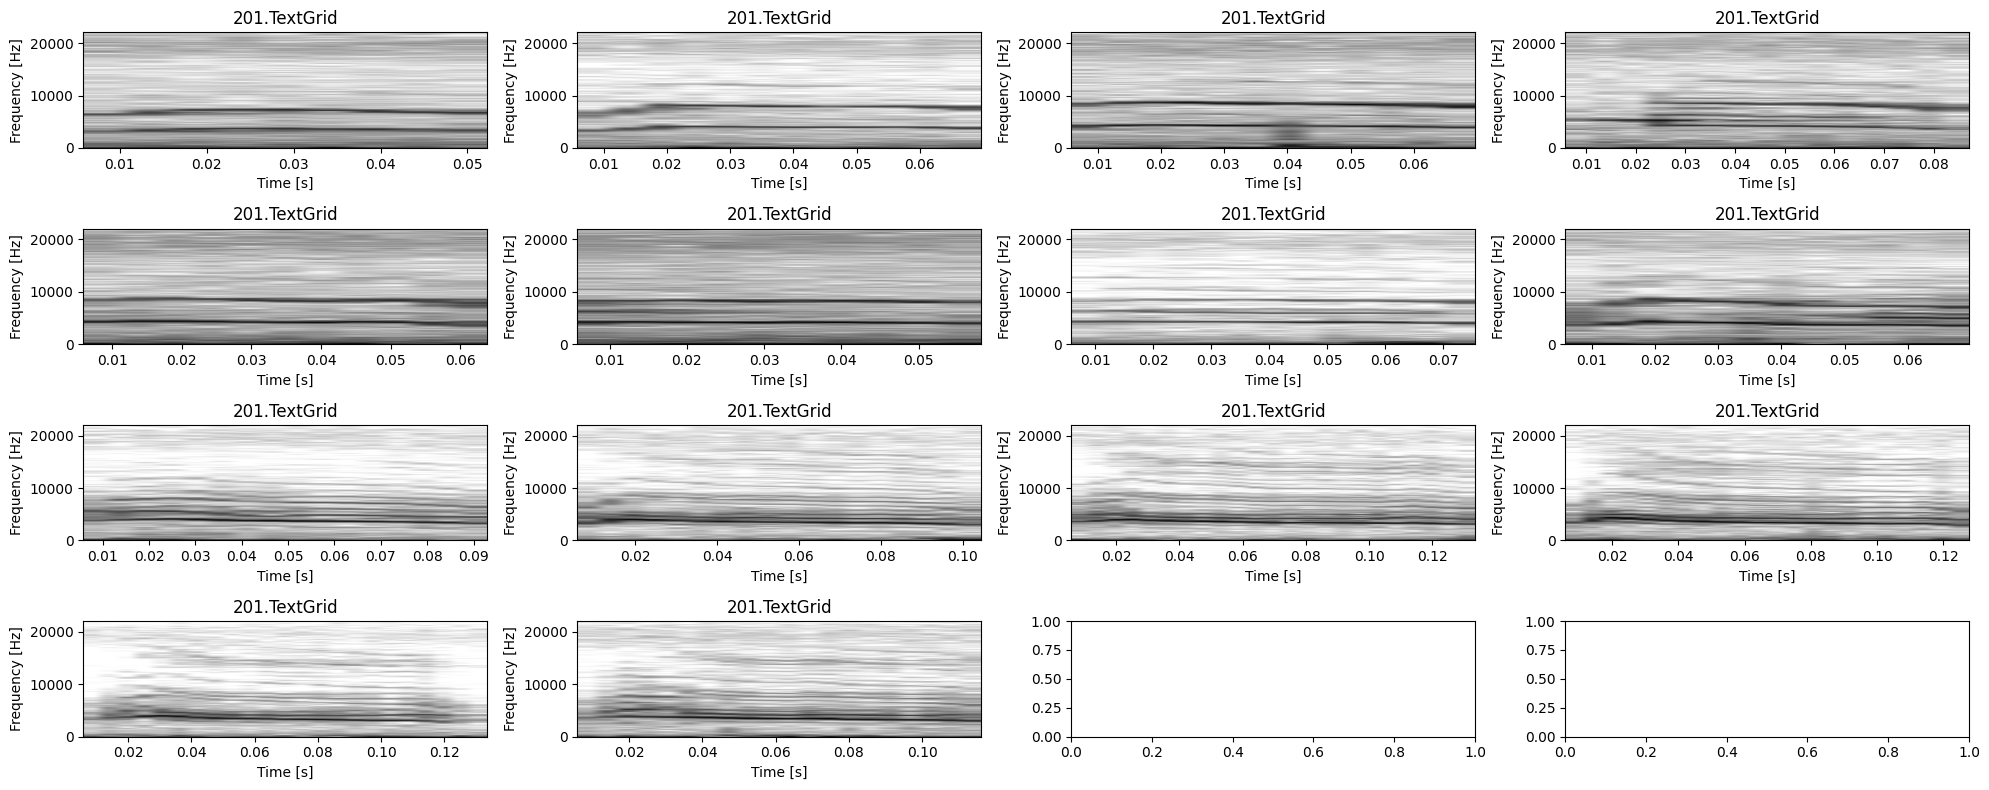

In [102]:
plot.plot_spectrogram_catalogue(audio_segments, "label", ncols=4, dynamic_range=DYNAMIC_RANGE)

In [103]:
audio_segments['spectrogram'] = audio_segments.apply(
    lambda row: compute.utils.transform_spectrogram_for_nn(
        data=row['waveform'],
        sr=row['sr'],
        values_type='float32',
        f_min = 1500, 
        f_max = 15000,
        window_length = WINDOW_LENGTH,
        resize=(128, 128)
    ),
    axis=1
)
audio_segments.head()

,waveform,label,sr,filename,spectrogram
0,"[0.025147252, 0.018524736, 0.026093327, 0.0258...",1,44100,201.TextGrid,"[[[0.011764807, 0.0122770015, 0.012789195, 0.0..."
1,"[0.020172736, 0.015442366, 0.020172736, 0.0142...",2,44100,201.TextGrid,"[[[0.009059372, 0.009443475, 0.0098275775, 0.0..."
2,"[-0.054597612, -0.057924133, -0.058381908, -0....",3,44100,201.TextGrid,"[[[0.009791163, 0.010417299, 0.011043437, 0.01..."
3,"[0.032258064, 0.029877622, 0.025849178, 0.0291...",4,44100,201.TextGrid,"[[[0.003403876, 0.005097091, 0.006790307, 0.00..."
4,"[0.045014802, 0.053559985, 0.04809717, 0.04147...",5,44100,201.TextGrid,"[[[0.026451806, 0.024625745, 0.022799686, 0.02..."


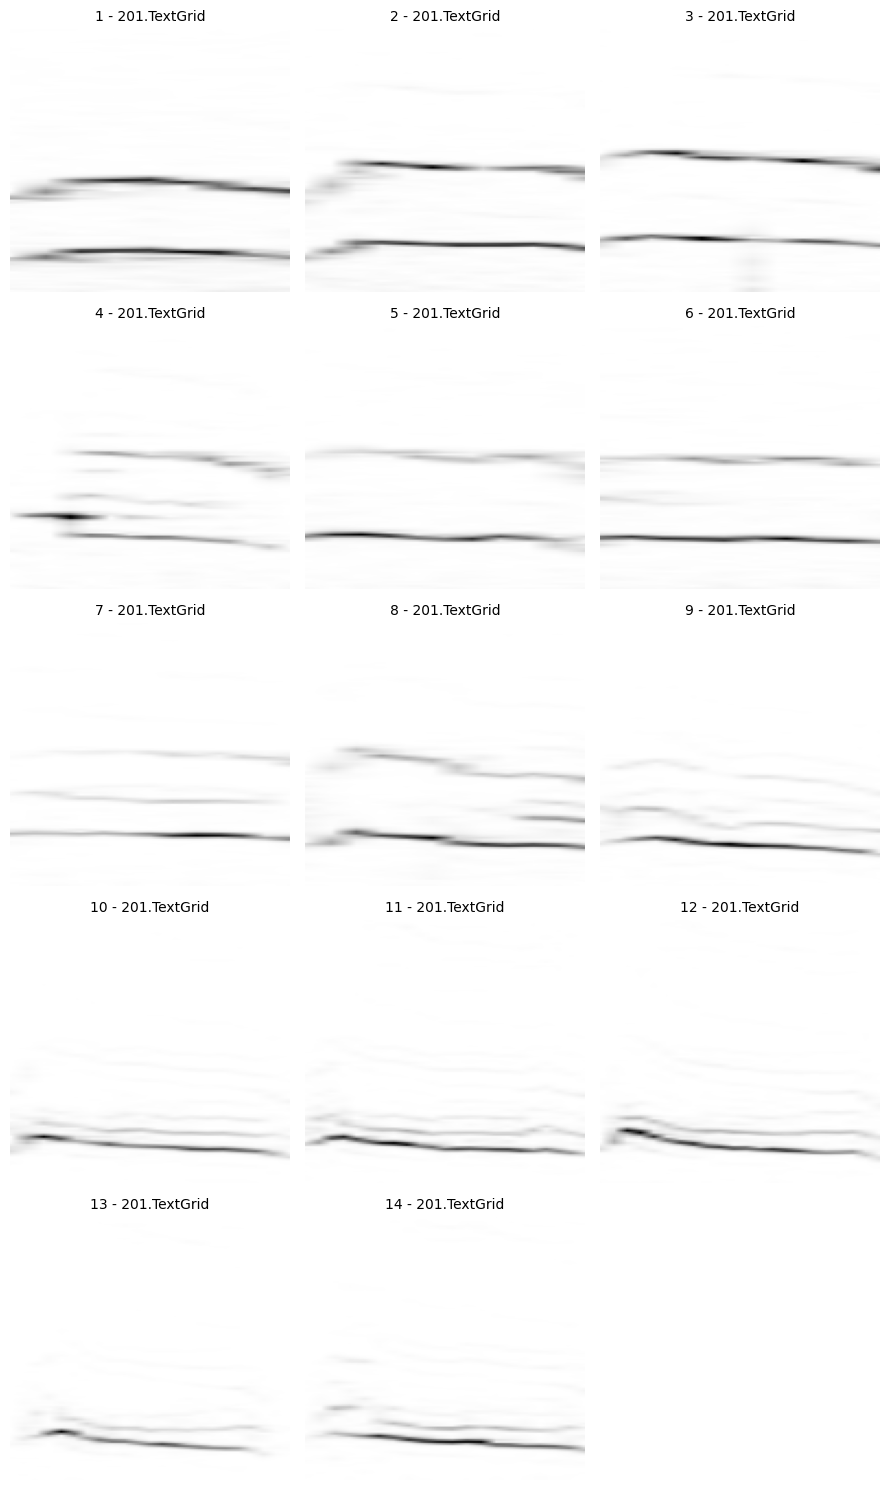

In [104]:
n_cols = 3
n_rows = (len(audio_segments) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols*3, n_rows*3))
axes = axes.flatten()

for i, (ax, spec) in enumerate(zip(axes, audio_segments['spectrogram'])):
    if spec.ndim == 3:
        spec_to_plot = spec[0]
    else:
        spec_to_plot = spec
    
    ax.imshow(spec_to_plot, origin='lower', aspect='auto', cmap='binary')
    ax.axis("off")
    ax.set_title(f"{audio_segments.iloc[i]['label']} - {audio_segments.iloc[i]['filename']}", fontsize=10)

for ax in axes[len(audio_segments):]:
    ax.axis("off")
    
plt.tight_layout()
plt.show()

## Read all files in a folder into DataFrame and plot spectrogram catalogue

In [105]:
df = handle.batch_read_files_to_df(data_folder+"/normalized")
df.head()

processing 307.wav
processing GT00025_G00220_Jafar_distance.wav
processing GT00024_G00219_Dagobert_distance.wav
processing 201.wav


,filename,sr,waveform
0,307.wav,44100,"[-0.027924437, -0.019623403, -0.021851253, -0...."
1,GT00025_G00220_Jafar_distance.wav,44100,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,GT00024_G00219_Dagobert_distance.wav,44100,"[-0.00048829615, -0.00045777764, -0.0004272591..."
3,201.wav,44100,"[-0.01861629, -0.019348735, -0.013183996, -0.0..."


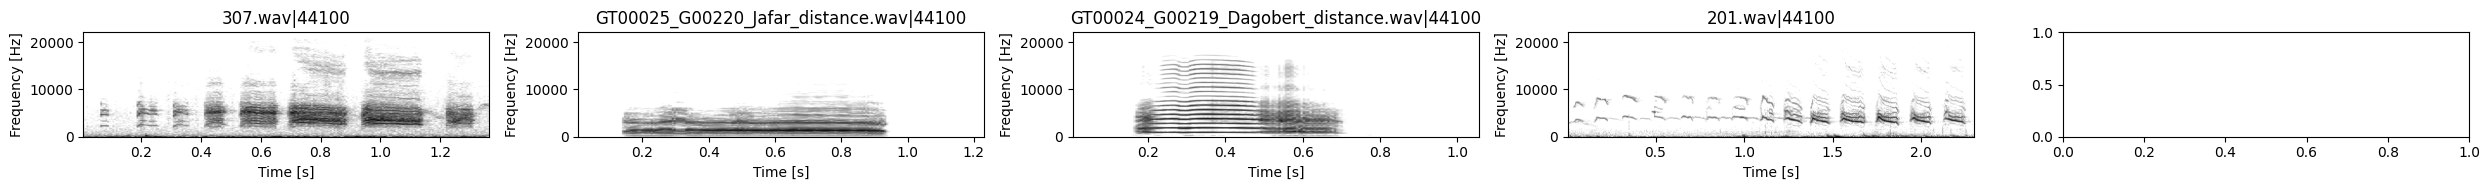

In [106]:
plot.plot_spectrogram_catalogue(df, "waveform", ncols=5, per_page=25, title_columns=["filename", "sr"], dynamic_range=55)

## Future

- Tokuda NLM
- Yin pitch tracking + Pitch tracking wrapper
- modulation spectra
- event detection/segmentation
- different noise reduction approaches
- dt(f)w
- autocorrelation + crosscorr
- spectral flux